# Feature Engineering

This notebook adds a small number of simple engineered property features and one first-pass school district geography feature. The test set remains June 2026, and the training set remains the 5 months immediately before June 2026.

## Load Updated Data

In [14]:
# import dependencies
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

import geopandas as gpd

pd.set_option('display.float_format', '{:,.3f}'.format)

In [2]:
# paths and constants
target_col = 'ClosePrice'

cleaned_train_path = 'data_clean/cleaned_train_not_encoded.csv'
cleaned_test_path = 'data_clean/cleaned_test_not_encoded.csv'

leakage_cols = [
    'ListPrice',
    'OriginalListPrice',
    'DaysOnMarket',
    'PurchaseContractDate'
]

In [3]:
# columns from the preprocessing notebook
required_cleaned_cols = [
    'CloseDate',
    'CloseMonth',
    target_col,
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'YearBuilt',
    'Latitude',
    'Longitude'
]

expected_train_months = ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05']
expected_test_months = ['2026-06']

In [4]:
# load cleaned train/test data from 02_preprocessing.ipynb
train = pd.read_csv(cleaned_train_path)
test = pd.read_csv(cleaned_test_path)

missing_required_cols = [
    col for col in required_cleaned_cols
    if col not in train.columns or col not in test.columns
]
if missing_required_cols:
    raise ValueError(f'Cleaned files are missing required columns: {missing_required_cols}')

train['CloseDate'] = pd.to_datetime(train['CloseDate'], errors='coerce')
test['CloseDate'] = pd.to_datetime(test['CloseDate'], errors='coerce')
train['CloseMonth'] = train['CloseMonth'].astype(str)
test['CloseMonth'] = test['CloseMonth'].astype(str)

train_months = sorted(train['CloseMonth'].dropna().unique())
test_months = sorted(test['CloseMonth'].dropna().unique())
if train_months != expected_train_months or test_months != expected_test_months:
    raise ValueError(
        f'Expected train months {expected_train_months} and test months {expected_test_months}; '
        f'found train months {train_months} and test months {test_months}.'
    )

print('Loaded cleaned train/test files.')
print('Train date range:', train['CloseDate'].min(), 'to', train['CloseDate'].max())
print('Test date range:', test['CloseDate'].min(), 'to', test['CloseDate'].max())
print('Train months:', train_months)
print('Test months:', test_months)
print('Train shape:', train.shape)
print('Test shape:', test.shape)

Loaded cleaned train/test files.
Train date range: 2026-01-01 00:00:00 to 2026-05-31 00:00:00
Test date range: 2026-06-01 00:00:00 to 2026-06-30 00:00:00
Train months: ['2026-01', '2026-02', '2026-03', '2026-04', '2026-05']
Test months: ['2026-06']
Train shape: (51267, 37)
Test shape: (12856, 37)


## Baseline Feature Set

The old baseline feature set below matches the expanded feature set from the previous model comparison notebook.

In [5]:
# same expanded feature set as the previous notebook
old_numeric_features = [
    'LivingArea',
    'BedroomsTotal',
    'BathroomsTotalInteger',
    'LotSizeAcres',
    'YearBuilt',
    'GarageSpaces',
    'ParkingTotal',
    'AssociationFee'
]

missing_indicator_cols = [col for col in train.columns if col.endswith('_missing')]
old_numeric_features = old_numeric_features + missing_indicator_cols

location_features = [
    'City',
    'CountyOrParish',
    'PostalCode',
    'MLSAreaMajor',
    'HighSchoolDistrict'
]

old_baseline_features = old_numeric_features + location_features
old_baseline_features = [
    col for col in old_baseline_features
    if col in train.columns and col in test.columns and col not in leakage_cols
]

print('Old baseline features:')
print(old_baseline_features)
print('Number of old baseline features before encoding:', len(old_baseline_features))

Old baseline features:
['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'YearBuilt', 'GarageSpaces', 'ParkingTotal', 'AssociationFee', 'LotSizeAcres_missing', 'GarageSpaces_missing', 'AssociationFee_missing', 'City', 'CountyOrParish', 'PostalCode', 'MLSAreaMajor', 'HighSchoolDistrict']
Number of old baseline features before encoding: 16


## Engineer Simple Property Features

`PropertyAge` may capture age, depreciation, or newness. `BedBathRatio` may capture layout balance. `LivingAreaPerBedroom` may capture average bedroom density and whether the home feels spacious or cramped. `AmenityCount` captures a simple count of common high-value property amenities.

In [6]:
# add simple engineered property features
def yes_no_to_int(series):
    values = series.astype('string').str.strip().str.upper()
    return values.map({'TRUE': 1, 'FALSE': 0, 'YES': 1, 'NO': 0, '1': 1, '0': 0}).fillna(0).astype(int)


def add_property_features(df):
    df = df.copy()
    sale_year = pd.to_datetime(df['CloseDate'], errors='coerce').dt.year
    
    for col in ['YearBuilt', 'BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    
    df['PropertyAge'] = sale_year - df['YearBuilt']
    df.loc[df['PropertyAge'] < 0, 'PropertyAge'] = np.nan
    
    bedrooms_nonzero = df['BedroomsTotal'].replace(0, np.nan)
    bathrooms_nonzero = df['BathroomsTotalInteger'].replace(0, np.nan)
    
    df['BedBathRatio'] = df['BedroomsTotal'] / bathrooms_nonzero
    df['LivingAreaPerBedroom'] = df['LivingArea'] / bedrooms_nonzero
    
    amenity_count = pd.Series(0, index=df.index)
    for col in ['PoolPrivateYN', 'FireplaceYN', 'BasementYN', 'ViewYN', 'NewConstructionYN']:
        if col in df.columns:
            amenity_count = amenity_count + yes_no_to_int(df[col])
    
    if 'GarageSpaces' in df.columns:
        garage_present = pd.to_numeric(df['GarageSpaces'], errors='coerce').fillna(0).gt(0).astype(int)
        amenity_count = amenity_count + garage_present
    elif 'AttachedGarageYN' in df.columns:
        amenity_count = amenity_count + yes_no_to_int(df['AttachedGarageYN'])
    
    df['AmenityCount'] = amenity_count
    
    return df

train = add_property_features(train)
test = add_property_features(test)

engineered_property_features = ['PropertyAge', 'BedBathRatio', 'LivingAreaPerBedroom', 'AmenityCount']

train[engineered_property_features].describe()

,PropertyAge,BedBathRatio,LivingAreaPerBedroom,AmenityCount
count,"51,267.000","51,267.000","51,267.000","51,267.000"
mean,49.547,1.450,580.770,2.433
std,27.646,0.469,187.551,0.933
min,0.000,0.333,128.000,0.000
25%,27.000,1.000,449.000,2.000
50%,49.000,1.500,544.250,2.000
75%,70.000,1.500,670.667,3.000
max,225.000,6.000,"2,450.000",6.000


## Add School District Layer

In [15]:
# update this path if the boundary file is saved somewhere else
school_district_path = '../ca_school_district_areas_2024_25.geojson'

# set this manually after inspecting the printed boundary columns, if needed
school_district_name_col = None

In [16]:
# spatially join properties to school district boundaries
def choose_school_district_column(districts, preferred_col=None):
    print('School district boundary columns:')
    print(list(districts.columns))
    
    if preferred_col is not None and preferred_col in districts.columns:
        return preferred_col
    
    candidate_cols = [
        'SchoolDistrict',
        'DistrictName',
        'DISTRICT',
        'District',
        'NAME',
        'Name',
        'agencyname',
        'AgencyName',
        'LEA_NAME',
        'LEAName'
    ]
    for col in candidate_cols:
        if col in districts.columns:
            return col
    
    name_like_cols = [
        col for col in districts.columns
        if 'name' in col.lower() or 'district' in col.lower()
    ]
    if name_like_cols:
        return name_like_cols[0]
    
    return None


def add_school_district_feature(df):
    df = df.copy()
    df['SchoolDistrict'] = 'Unknown'
    
    if gpd is None:
        return df
    
    if not os.path.exists(school_district_path):
        print('School district boundary file was not found:', school_district_path)
        return df
    
    if 'Longitude' not in df.columns or 'Latitude' not in df.columns:
        print('Longitude and Latitude are required for the school district spatial join.')
        return df
    
    longitude = pd.to_numeric(df['Longitude'], errors='coerce')
    latitude = pd.to_numeric(df['Latitude'], errors='coerce')
    valid_coords = longitude.notna() & latitude.notna()
    
    if valid_coords.sum() == 0:
        print('No valid coordinates were available for the school district spatial join.')
        return df
    
    properties = df.loc[valid_coords, ['Longitude', 'Latitude']].copy()
    properties['_row_id'] = properties.index
    properties = gpd.GeoDataFrame(
        properties,
        geometry=gpd.points_from_xy(longitude.loc[valid_coords], latitude.loc[valid_coords]),
        crs='EPSG:4326'
    )
    
    districts = gpd.read_file(school_district_path)
    selected_name_col = choose_school_district_column(districts, school_district_name_col)
    print('Selected school district column:', selected_name_col)
    
    if selected_name_col is None:
        print('No school district name column was selected. SchoolDistrict will stay Unknown.')
        return df
    
    districts = districts.to_crs(properties.crs)
    joined = gpd.sjoin(
        properties,
        districts[[selected_name_col, 'geometry']],
        how='left',
        predicate='within'
    )
    joined = joined.drop_duplicates('_row_id')
    school_values = joined.set_index('_row_id')[selected_name_col].fillna('Unknown').astype(str)
    df.loc[school_values.index, 'SchoolDistrict'] = school_values
    
    return df


train = add_school_district_feature(train)
test = add_school_district_feature(test)

print('Train SchoolDistrict values:')
print(train['SchoolDistrict'].value_counts(dropna=False).head(10))
print('\nTest SchoolDistrict values:')
print(test['SchoolDistrict'].value_counts(dropna=False).head(10))

School district boundary columns:
['OBJECTID', 'Year', 'FedID', 'CDCode', 'CDSCode', 'CountyName', 'DistrictName', 'DistrictType', 'GradeLow', 'GradeHigh', 'GradeLowCensus', 'GradeHighCensus', 'AssistStatus', 'CongressUS', 'SenateCA', 'AssemblyCA', 'UpdateNotes', 'EnrollTotal', 'EnrollCharter', 'EnrollNonCharter', 'AAcount', 'AApct', 'AIcount', 'AIpct', 'AScount', 'ASpct', 'FIcount', 'FIpct', 'HIcount', 'HIpct', 'PIcount', 'PIpct', 'WHcount', 'WHpct', 'MRcount', 'MRpct', 'NRcount', 'NRpct', 'ELcount', 'ELpct', 'FOScount', 'FOSpct', 'HOMcount', 'HOMpct', 'MIGcount', 'MIGpct', 'SWDcount', 'SWDpct', 'SEDcount', 'SEDpct', 'DistrctAreaSqMi', 'Shape__Area', 'Shape__Length', 'geometry']
Selected school district column: DistrictName
School district boundary columns:
['OBJECTID', 'Year', 'FedID', 'CDCode', 'CDSCode', 'CountyName', 'DistrictName', 'DistrictType', 'GradeLow', 'GradeHigh', 'GradeLowCensus', 'GradeHighCensus', 'AssistStatus', 'CongressUS', 'SenateCA', 'AssemblyCA', 'UpdateNotes', '

## Feature Sets for Comparison

In [17]:
# create old, engineered, and engineered plus school district feature sets
feature_sets = {
    'Old baseline features': old_baseline_features,
    'Engineered features': old_baseline_features + engineered_property_features,
    'Engineered + school district features': old_baseline_features + engineered_property_features + ['SchoolDistrict']
}

for feature_set_name, feature_cols in feature_sets.items():
    feature_sets[feature_set_name] = [
        col for col in feature_cols
        if col in train.columns and col in test.columns and col not in leakage_cols
    ]
    print(feature_set_name)
    print(feature_sets[feature_set_name])
    print('Number of features before encoding:', len(feature_sets[feature_set_name]))
    print()

Old baseline features
['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'YearBuilt', 'GarageSpaces', 'ParkingTotal', 'AssociationFee', 'LotSizeAcres_missing', 'GarageSpaces_missing', 'AssociationFee_missing', 'City', 'CountyOrParish', 'PostalCode', 'MLSAreaMajor', 'HighSchoolDistrict']
Number of features before encoding: 16

Engineered features
['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'YearBuilt', 'GarageSpaces', 'ParkingTotal', 'AssociationFee', 'LotSizeAcres_missing', 'GarageSpaces_missing', 'AssociationFee_missing', 'City', 'CountyOrParish', 'PostalCode', 'MLSAreaMajor', 'HighSchoolDistrict', 'PropertyAge', 'BedBathRatio', 'LivingAreaPerBedroom', 'AmenityCount']
Number of features before encoding: 20

Engineered + school district features
['LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeAcres', 'YearBuilt', 'GarageSpaces', 'ParkingTotal', 'AssociationFee', 'LotSizeAcres_missing', 'GarageSpaces_missing', 'Associat

## Modeling Setup

In [18]:
# simple preprocessing and model helpers
categorical_feature_candidates = set(location_features + ['SchoolDistrict'])


def split_feature_types(feature_cols):
    categorical_cols = [col for col in feature_cols if col in categorical_feature_candidates]
    numeric_cols = [col for col in feature_cols if col not in categorical_cols]
    return numeric_cols, categorical_cols


def prepare_model_frames(feature_cols):
    X_train = train[feature_cols].copy()
    X_test = test[feature_cols].copy()
    numeric_cols, categorical_cols = split_feature_types(feature_cols)
    
    for col in numeric_cols:
        X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    
    for col in categorical_cols:
        X_train[col] = X_train[col].where(X_train[col].notna(), 'Unknown').astype(str).str.strip()
        X_test[col] = X_test[col].where(X_test[col].notna(), 'Unknown').astype(str).str.strip()
        X_train.loc[X_train[col] == '', col] = 'Unknown'
        X_test.loc[X_test[col] == '', col] = 'Unknown'
    
    return X_train, X_test, numeric_cols, categorical_cols


def build_pipeline(model, numeric_cols, categorical_cols):
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
    ])
    
    preprocessor = ColumnTransformer(transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])
    
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

In [19]:
# models match the Week 6 instructions
model_specs = [
    ('Linear Regression', lambda: LinearRegression()),
    ('Decision Tree', lambda: DecisionTreeRegressor(
        max_depth=10,
        min_samples_leaf=20,
        random_state=42
    )),
    ('Random Forest', lambda: RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
]

## Train and Evaluate Models

In [20]:
# train and evaluate each model on each feature set
def percentage_error_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = np.where(y_true == 0, np.nan, y_true)
    absolute_percentage_errors = (np.abs(y_true - y_pred) / denominator) * 100
    return np.nanmedian(absolute_percentage_errors), np.nanmean(absolute_percentage_errors)


y_train = pd.to_numeric(train[target_col], errors='coerce')
y_test = pd.to_numeric(test[target_col], errors='coerce')

results = []
fitted_models = {}

for feature_set_name, feature_cols in feature_sets.items():
    X_train, X_test, numeric_cols, categorical_cols = prepare_model_frames(feature_cols)
    
    for model_name, model_factory in model_specs:
        print('Training', model_name, 'with', feature_set_name)
        model = build_pipeline(model_factory(), numeric_cols, categorical_cols)
        model.fit(X_train, y_train)
        
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
        test_mdape, test_mape = percentage_error_metrics(y_test, test_pred)
        
        fitted_models[(feature_set_name, model_name)] = model
        results.append({
            'Model': model_name,
            'Feature Set': feature_set_name,
            'Train R²': r2_score(y_train, train_pred),
            'Test R²': r2_score(y_test, test_pred),
            'Test MAE': mean_absolute_error(y_test, test_pred),
            'Test RMSE': np.sqrt(mean_squared_error(y_test, test_pred)),
            'Test MdAPE': test_mdape,
            'Test MAPE': test_mape
        })

results_df = pd.DataFrame(results)
results_df

Training Linear Regression with Old baseline features
Training Decision Tree with Old baseline features
Training Random Forest with Old baseline features
Training Linear Regression with Engineered features
Training Decision Tree with Engineered features
Training Random Forest with Engineered features
Training Linear Regression with Engineered + school district features


/Users/mario/Desktop/Code/IDX/ca-property-close-price-prediction/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Training Decision Tree with Engineered + school district features


/Users/mario/Desktop/Code/IDX/ca-property-close-price-prediction/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Training Random Forest with Engineered + school district features


/Users/mario/Desktop/Code/IDX/ca-property-close-price-prediction/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [5] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


,Model,Feature Set,Train R²,Test R²,Test MAE,Test RMSE,Test MdAPE,Test MAPE
0,Linear Regression,Old baseline features,0.790,0.794,"294,125.993","472,512.277",19.983,28.344
1,Decision Tree,Old baseline features,0.692,0.672,"359,431.712","596,048.035",20.457,33.539
2,Random Forest,Old baseline features,0.864,0.788,"264,971.292","479,574.260",13.310,22.135
3,Linear Regression,Engineered features,0.799,0.802,"283,869.376","462,731.763",18.849,26.526
4,Decision Tree,Engineered features,0.693,0.672,"360,408.092","596,688.325",20.668,33.589
5,Random Forest,Engineered features,0.868,0.786,"266,400.740","481,382.570",13.347,22.198
6,Linear Regression,Engineered + school district features,0.829,0.834,"262,175.794","424,338.419",17.378,24.537
7,Decision Tree,Engineered + school district features,0.694,0.673,"358,923.811","594,963.851",20.423,33.331
8,Random Forest,Engineered + school district features,0.871,0.792,"260,981.791","475,087.027",12.896,21.603


## Compare Old vs New Feature Sets

In [21]:
# compare model performance across feature sets
results_sorted = results_df.sort_values('Test R²', ascending=False).reset_index(drop=True)
results_sorted

,Model,Feature Set,Train R²,Test R²,Test MAE,Test RMSE,Test MdAPE,Test MAPE
0,Linear Regression,Engineered + school district features,0.829,0.834,"262,175.794","424,338.419",17.378,24.537
1,Linear Regression,Engineered features,0.799,0.802,"283,869.376","462,731.763",18.849,26.526
2,Linear Regression,Old baseline features,0.790,0.794,"294,125.993","472,512.277",19.983,28.344
3,Random Forest,Engineered + school district features,0.871,0.792,"260,981.791","475,087.027",12.896,21.603
4,Random Forest,Old baseline features,0.864,0.788,"264,971.292","479,574.260",13.310,22.135
5,Random Forest,Engineered features,0.868,0.786,"266,400.740","481,382.570",13.347,22.198
6,Decision Tree,Engineered + school district features,0.694,0.673,"358,923.811","594,963.851",20.423,33.331
7,Decision Tree,Old baseline features,0.692,0.672,"359,431.712","596,048.035",20.457,33.539
8,Decision Tree,Engineered features,0.693,0.672,"360,408.092","596,688.325",20.668,33.589


In [22]:
# best model within each feature set
best_by_feature_set = (
    results_df
    .sort_values('Test R²', ascending=False)
    .groupby('Feature Set', as_index=False)
    .first()
)

best_by_feature_set[[
    'Feature Set',
    'Model',
    'Train R²',
    'Test R²',
    'Test MAE',
    'Test RMSE',
    'Test MdAPE',
    'Test MAPE'
]].sort_values('Test R²', ascending=False)

,Feature Set,Model,Train R²,Test R²,Test MAE,Test RMSE,Test MdAPE,Test MAPE
0,Engineered + school district features,Linear Regression,0.829,0.834,"262,175.794","424,338.419",17.378,24.537
1,Engineered features,Linear Regression,0.799,0.802,"283,869.376","462,731.763",18.849,26.526
2,Old baseline features,Linear Regression,0.790,0.794,"294,125.993","472,512.277",19.983,28.344


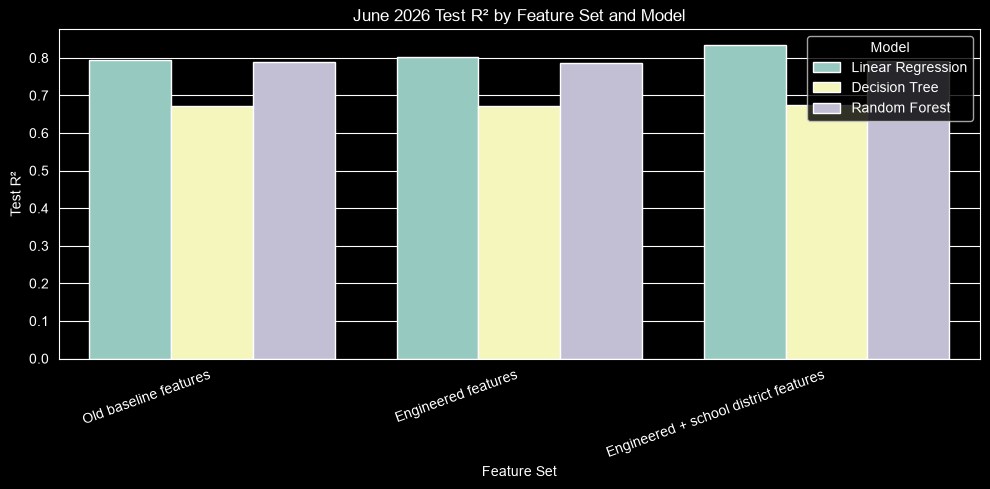

In [23]:
# plot test R squared values
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x='Feature Set', y='Test R²', hue='Model')
plt.title('June 2026 Test R² by Feature Set and Model')
plt.xlabel('Feature Set')
plt.ylabel('Test R²')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()